In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/breast-cancer-wisconsin-data/data.csv


## Importing libraries 

In [28]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

import keras
from keras.models import Sequential
from keras.layers import Dense

In [29]:
BC_df = pd.read_csv('../input/breast-cancer-wisconsin-data/data.csv')
print("The shape of our dataset :"+str(BC_df.shape))
BC_df.head()

The shape of our dataset :(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [30]:
#print all the columns of the dataset
print(BC_df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


In [31]:
# drop the unnecessary columns as:id
BC_df.drop(columns={'id'},inplace = True)


## Get a statistical insight about our dataset

In [32]:
BC_df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [33]:
BC_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

## Check for the missing values and deal with them

In [34]:
BC_df.isnull().sum()

diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed: 32                569
dtype: i

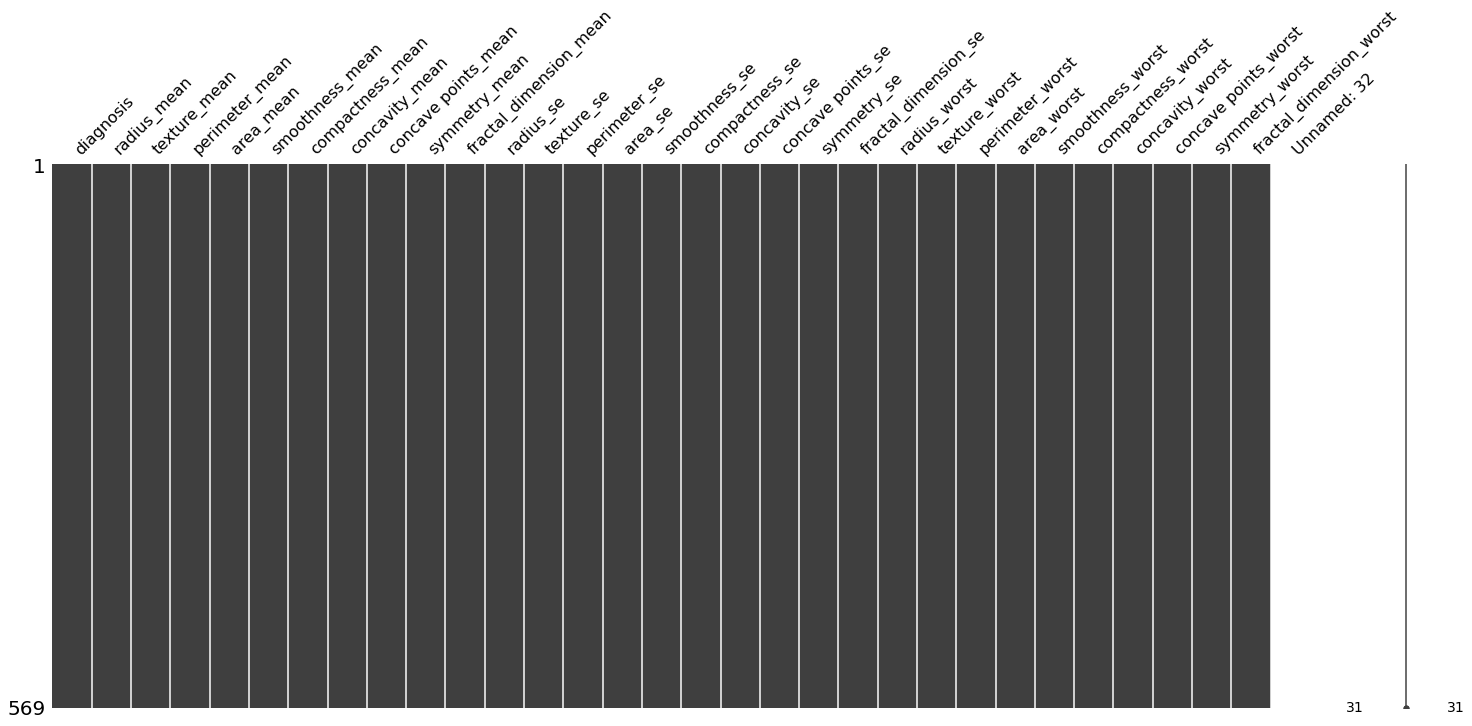

In [35]:
# visualizing the missing values using missingo
import missingno as msno
msno.matrix(BC_df)
plt.show()

#### **Note:**The column of the Unnamed: 32 has null values ; meanwhile the others don't have any null value , so we will drop the whole column(Unnamed: 32)

In [36]:
# drop the Unnamed: 32 column
BC_df.dropna(axis=1,inplace=True)

In [37]:
# print the shape of the dataset after dropping the Unnamed: 32 column
BC_df.shape

(569, 31)

## Exploratory Data analysis

> ###### Our data has diagnosis as [label class] where ; 
* B -> Benign  
* M -> malignant

In [38]:
diagnosis_set = set(BC_df['diagnosis'])
print(diagnosis_set)

{'M', 'B'}


B    357
M    212
Name: diagnosis, dtype: int64


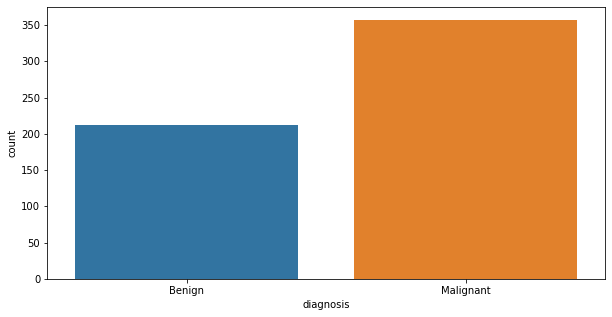

In [39]:
# Checking for imbalance 
BC_count = BC_df['diagnosis'].value_counts()
print(BC_count)
plt.figure(figsize=(10,5))
g = sns.countplot(BC_df['diagnosis'])
g.set_xticklabels(['Benign','Malignant'])
plt.show()

## Define the features(x) and class_label(y)

In [40]:
X = BC_df.drop(columns={'diagnosis'})
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [41]:
y = BC_df['diagnosis']
y

0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: diagnosis, Length: 569, dtype: object

## Dealing imbalance dataset 
* Benign ->357
* malignant ->212

In [42]:
#using SMOTE from imblearn
import imblearn
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=0)
X_res, y_res = smote.fit_resample(X,y)
print('Resampled dataset shape %s' % y_res.value_counts())



Resampled dataset shape B    357
M    357
Name: diagnosis, dtype: int64


In [43]:
print(y_res)

0      M
1      M
2      M
3      M
4      M
      ..
709    M
710    M
711    M
712    M
713    M
Name: diagnosis, Length: 714, dtype: object


## Get the data ready for training it via the model

In [44]:
enoder = LabelEncoder().fit(y_res)
y_res = enoder.transform(y_res)
# BC_df.head()
y_res
#Note that the value for M -> 1 | B -> 0

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

## Spliiting the dataset to training set(80%)and testing set(20%)

In [45]:
x_train,x_test,y_train,y_test = train_test_split(X_res,y_res,
                                test_size=0.2,random_state=0)
print('Shape of the training set:'+" "+str(x_train.shape))
print('Size of the training set:'+" "+str(x_train.shape[0]))

print('Shape of the testing set:'+" "+str(x_test.shape))
print('Size of the testing set:'+" "+str(x_test.shape[0]))

Shape of the training set: (571, 30)
Size of the training set: 571
Shape of the testing set: (143, 30)
Size of the testing set: 143


## Preprocessing our tarining set

In [46]:
scaler = StandardScaler().fit(x_train)
train_scaled = scaler.transform(x_train)
test_scaled = scaler.transform(x_test)


## Build the model 

In [47]:
model = Sequential([
    Dense(32 ,activation='relu',input_shape=(30,)),
    Dense(32 ,activation='relu'),
    Dense(1,activation='sigmoid')
])
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 32)                992       
_________________________________________________________________
dense_4 (Dense)              (None, 32)                1056      
_________________________________________________________________
dense_5 (Dense)              (None, 1)                 33        
Total params: 2,081
Trainable params: 2,081
Non-trainable params: 0
_________________________________________________________________


In [48]:
model.compile(optimizer='sgd',
             loss='binary_crossentropy',
             metrics=['accuracy'])
model.fit(train_scaled , y_train 
         ,epochs=100,batch_size=32 )
model.save('model_breast_cancer.h5')

Epoch 1/100
18/18 [==============================] - 0s 928us/step - loss: 0.8164 - accuracy: 0.4221
Epoch 2/100
18/18 [==============================] - 0s 825us/step - loss: 0.6387 - accuracy: 0.6515
Epoch 3/100
18/18 [==============================] - 0s 853us/step - loss: 0.5292 - accuracy: 0.8231
Epoch 4/100
18/18 [==============================] - 0s 902us/step - loss: 0.4489 - accuracy: 0.8984
Epoch 5/100
18/18 [==============================] - 0s 885us/step - loss: 0.3863 - accuracy: 0.9264
Epoch 6/100
18/18 [==============================] - 0s 1ms/step - loss: 0.3364 - accuracy: 0.9282
Epoch 7/100
18/18 [==============================] - 0s 1ms/step - loss: 0.2965 - accuracy: 0.9335
Epoch 8/100
18/18 [==============================] - 0s 1ms/step - loss: 0.2648 - accuracy: 0.9457
Epoch 9/100
18/18 [==============================] - 0s 1ms/step - loss: 0.2390 - accuracy: 0.9492
Epoch 10/100
18/18 [==============================] - 0s 1ms/step - loss: 0.2183 - accuracy: 0.9492

18/18 [==============================] - 0s 836us/step - loss: 0.0589 - accuracy: 0.9807
Epoch 82/100
18/18 [==============================] - 0s 975us/step - loss: 0.0585 - accuracy: 0.9807
Epoch 83/100
18/18 [==============================] - 0s 930us/step - loss: 0.0582 - accuracy: 0.9825
Epoch 84/100
18/18 [==============================] - 0s 951us/step - loss: 0.0578 - accuracy: 0.9807
Epoch 85/100
18/18 [==============================] - 0s 857us/step - loss: 0.0575 - accuracy: 0.9807
Epoch 86/100
18/18 [==============================] - 0s 882us/step - loss: 0.0571 - accuracy: 0.9807
Epoch 87/100
18/18 [==============================] - 0s 768us/step - loss: 0.0568 - accuracy: 0.9825
Epoch 88/100
18/18 [==============================] - 0s 910us/step - loss: 0.0565 - accuracy: 0.9807
Epoch 89/100
18/18 [==============================] - 0s 983us/step - loss: 0.0562 - accuracy: 0.9825
Epoch 90/100
18/18 [==============================] - 0s 901us/step - loss: 0.0559 - accuracy: 

In [49]:
pretrained_model = keras.models.load_model('./model_breast_cancer.h5')
eval_score = pretrained_model.evaluate(test_scaled,y_test)
print('The loss of the evaluation :'+' '+str(eval_score[0]))
print('The accuracy of the evaluation :'+' '+str(eval_score[1]))


5/5 [==============================] - 0s 1ms/step - loss: 0.0583 - accuracy: 0.9720
The loss of the evaluation : 0.05832282081246376
The accuracy of the evaluation : 0.9720279574394226


## Predict the testset

In [50]:
y_pred = pretrained_model.predict_classes(test_scaled)
y_pred

array([[1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
    

## Evaluation the performance of our model

In [51]:
target_list=['benign','malignant']
classification_report(y_true=y_test,y_pred=y_pred
                      ,output_dict = True,target_names=target_list)

{'benign': {'precision': 0.9625,
  'recall': 0.9871794871794872,
  'f1-score': 0.9746835443037976,
  'support': 78},
 'malignant': {'precision': 0.9841269841269841,
  'recall': 0.9538461538461539,
  'f1-score': 0.96875,
  'support': 65},
 'accuracy': 0.972027972027972,
 'macro avg': {'precision': 0.973313492063492,
  'recall': 0.9705128205128206,
  'f1-score': 0.9717167721518988,
  'support': 143},
 'weighted avg': {'precision': 0.9723304473304473,
  'recall': 0.972027972027972,
  'f1-score': 0.9719864787111623,
  'support': 143}}

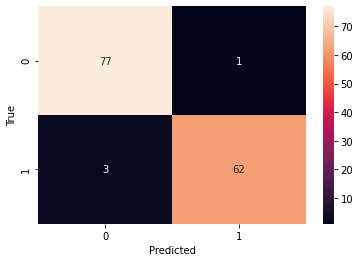

In [52]:
CV = confusion_matrix(y_true=y_test,y_pred=y_pred)
sns.heatmap(CV,annot=True )
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()